# **Zero Loss Global Minima Experiments w/ Multiple Datasets**


## **Step No. 1 - Importing from Libraries and Previous Experiments**


In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

import numpy as np
from numpy.linalg import pinv

import random
import copy
from copy import deepcopy

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
import seaborn as sns
import pandas as pd

from sklearn.datasets import make_blobs
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.svm import LinearSVC
import statistics

import io
from PIL import Image
import plotly.graph_objects as go
from plotly.subplots import make_subplots

> **NOTE: Before implementing the dataset type:**
>* I’m bringing my **SLS code** from **Experiment #1** so I can verify whether the dataset is Sequentially Linearly Separable (SLS).
> * I am also bringing code to **plot truncation maps** from **Experiment #2.**


In [ ]:
def run_sls_analysis(x_train_flat, y_train_subset, selected_digits, strict_threshold=0.04):
    print("\n----------- STRICT SLS TEST RESULTS -----------\n")
    class_means = {}
    for label in np.unique(y_train_subset):
        class_images = x_train_flat[y_train_subset == label]
        mean_vector = np.mean(class_images, axis=0)
        class_means[label] = mean_vector

    means_stack = np.stack([class_means[cls] for cls in selected_digits])
    barycenter = np.mean(means_stack, axis=0)

    def sls_experiment(strict=True, error_threshold=strict_threshold):
        x_mod = x_train_flat.copy()
        y_mod = y_train_subset.copy()

        separation_results = {}
        misclassified_counts = {}
        class_means_copy = class_means.copy()
        pn_points = {}
        error_rate_dict = {}

        for n in selected_digits:
            if len(np.unique(y_mod)) == 1:
              separation_results[n] = True
              misclassified_counts[n] = 0
              error_rate_dict[n] = 0
              if strict:
                  print(f"Class {n} Separation Error Rate: 0% - Only Class Left")
              continue

            y_binary = np.where(y_mod == n, 1, -1)
            clf = LinearSVC(C=1.0, max_iter=10000)
            clf.fit(x_mod, y_binary)

            preds = clf.predict(x_mod)
            error_rate = np.mean(preds[y_binary == 1] != 1)

            is_perfect = error_rate == 0.0
            separation_results[n] = is_perfect
            misclassified_counts[n] = np.sum(preds != y_binary)
            error_rate_dict[n] = error_rate

            if strict:
                print(f"Class {n} Separation Error Rate: {error_rate*100:.2f}%")

            if not is_perfect and (strict or error_rate > error_threshold):
                break

            w = clf.coef_[0]
            b = clf.intercept_[0]
            direction = barycenter - class_means_copy[n]
            t = -(np.dot(w, class_means_copy[n]) + b) / np.dot(w, direction)
            p_n = class_means_copy[n] + t * direction
            pn_points[n] = p_n

            x_mod[y_mod == n] = p_n
            keep_mask = y_mod != n
            x_mod = x_mod[keep_mask]
            y_mod = y_mod[keep_mask]

        return separation_results, misclassified_counts, error_rate_dict, error_threshold, pn_points

    results_strict, errors_strict, error_rate_dict_strict, _, _ = sls_experiment(strict=True)
    results_relaxed, errors_relaxed, error_rate_dict_relaxed, error_threshold, pn_points = sls_experiment(strict=False)

    if all(results_strict.values()):
        print("\n- ✅ DATASET IS SLS UNDER STRICT CONDITIONS.")
    else:
        print("\n❌ Dataset is NOT SLS under strict conditions.")

    processed_classes_strict = list(error_rate_dict_strict.keys())
    processed_classes_relaxed = list(error_rate_dict_relaxed.keys())
    errors_strict_pct = [error_rate_dict_strict[d] * 100 for d in processed_classes_strict]
    errors_relaxed_pct = [error_rate_dict_relaxed[d] * 100 for d in processed_classes_relaxed]
    error_threshold_pct = error_threshold * 100

def plot_truncated(Ws, bs, X_train, y_train):
    L = len(Ws)
    L1 = len(bs)

    W_cum_chain = []
    b_cum_chain = []

    for ell in range(L):
        if ell == 0:
            Wcum = Ws[0]
            bcum = bs[0]
        else:
            Wcum = Ws[ell] @ W_cum_chain[-1]
            btemp = 0
            for k in range(ell):
                chain = Ws[ell]
                for j in range(ell-1, k, -1):
                    chain = chain @ Ws[j]
                btemp += chain @ bs[k]
            bcum = btemp + bs[ell]

        W_cum_chain.append(Wcum)
        b_cum_chain.append(bcum)

    # Compute Truncated Data (Using Truncation Map Definition)
    X_trunc_chain = [X_train]


    for ell in range(L-1):
        Wcum = W_cum_chain[ell]
        bcum = b_cum_chain[ell]

        W_pinv = np.linalg.pinv(Wcum)
        Z = X_trunc_chain[ell] @ Wcum.T + bcum # WARNING: This is wrong. (10/11 - Don't know why this is here?)
        Z_relu = np.maximum(Z, 0)

        X_trunc = (W_pinv @ (Z_relu.T - bcum[:, np.newaxis])).T
        X_trunc_chain.append(X_trunc)

    titles = ["Original Data"] + [f"Truncated Layer {i+1}" for i in range(L-1)] + ["Final Output"]
    data_list = X_trunc_chain

    model = ExplicitReLU(Ws, bs).eval()
    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    model.eval()
    with torch.no_grad():
        X_out = model(X_train_tensor).numpy()
    data_list.append(X_out)

    num_subplots = L + 1
    fig = plt.figure(figsize=(5 * num_subplots, 5))

    for i in range(num_subplots):
        dim = data_list[i].shape[1]
        if dim == 3:
            ax = fig.add_subplot(1, num_subplots, i + 1, projection='3d')
        else:
            ax = fig.add_subplot(1, num_subplots, i + 1)

        for c in np.unique(y_train):
            idx = y_train == c
            if dim == 3:
                ax.scatter(
                    data_list[i][idx, 0],
                    data_list[i][idx, 1],
                    data_list[i][idx, 2],
                    s=10,
                    label=f"Class {c}"
                )
                ax.set_zlabel("X3")
                ax.view_init(elev=20, azim=30)
            else:
                ax.scatter(
                    data_list[i][idx, 0],
                    data_list[i][idx, 1],
                    s=10,
                    label=f"Class {c}"
                )

        ax.set_title(titles[i])
        ax.set_xlabel("X1")
        ax.set_ylabel("X2")
        if i == 0:
            ax.legend(loc='upper left', fontsize=8)

    plt.tight_layout()
    plt.show()


## **Step No. 2 - Generating Synthetic Datasets + Zero Loss Construction Parameters**


> **(2.c) - Synthetic Dataset Type (c): 2 Non-SLS & Non-Concentric Classes (Figure 1a in Ewa25).**

<img src="https://drive.google.com/uc?id=1XVAM4nMKx44yMudCte-DxUqjxq_gQOdP" width="300">

DATA: Using Synthetic Dataset Type (c): 2 Non-SLS & Non-Concentric Classes (Figure 1a in Ewa25).

----------- VISUALIZING THE GENERATED SYNTHETIC DATA -----------



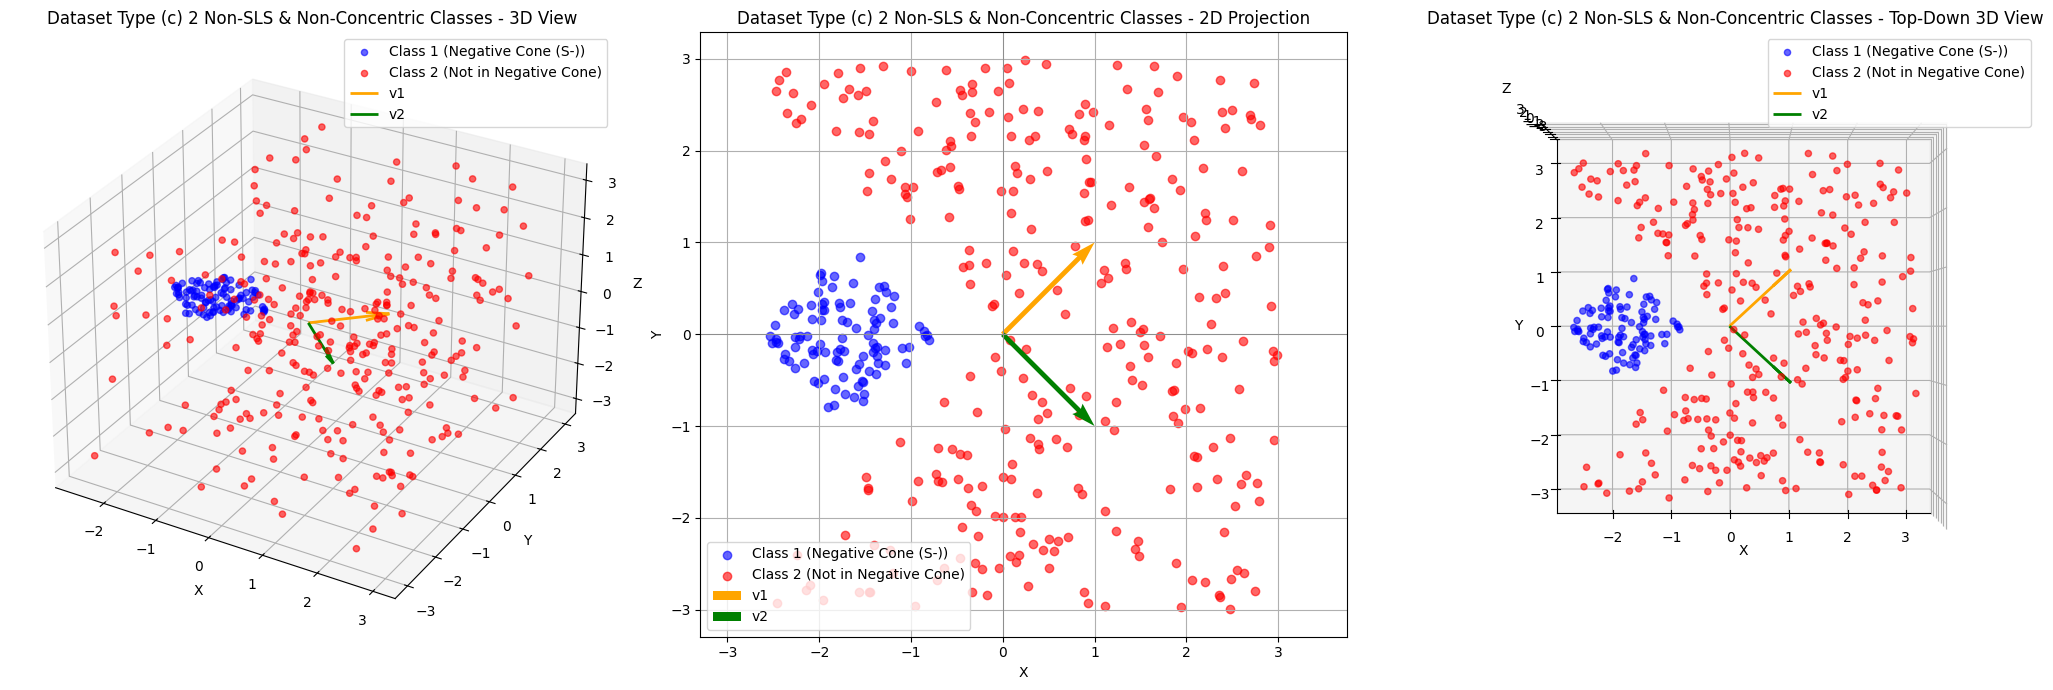


----------- STRICT SLS TEST RESULTS -----------

Class 0 Separation Error Rate: 18.75%

❌ Dataset is NOT SLS under strict conditions.

^ THIS DATASET IS NOT SLS, WHICH IS THE GOAL ✅
------------------------------------------------


In [ ]:
def generate_dataset_c_and_cone_parameters(sep):

    # ----------------------------------------------------------------------------------------------------------------------
    # Generate Synthetic Data [Type (c) from Proposition 3.1]
    # ----------------------------------------------------------------------------------------------------------------------

    selected_digits = [0,1]
    Q = len(selected_digits)
    L = Q + 1

    print(f"DATA: Using Synthetic Dataset Type (c): 2 Non-SLS & Non-Concentric Classes (Figure 1a in Ewa25).\n")
    dataset_info = "DATA: Using Synthetic Dataset Type (c): 2 Non-SLS & Non-Concentric Classes (Figure 1a in Ewa25)"

    p = np.array([0, 0, 0])
    v1 = np.array([1, 1, 0])
    v2 = np.array([1, -1, 0])

    # Generate Class 1 (Blue) - Points INSIDE the NEGATIVE cone S⁻(p, {v₁, v₂})
    # S⁻(p, {v₁, v₂}) = { p + Σ aᵢ vᵢ | aᵢ ≤ 0 }
    # Points in S⁻ will later be "collapsed" to p by the truncation map τ₍W,b₎.

    def generate_class1(n=100):
        coeffs = -np.abs(np.random.rand(n, 2)) - sep
        return p + coeffs[:, 0][:, None]*v1 + coeffs[:, 1][:, None]*v2

    # Generate Class 2 (Red) - Points OUTSIDE the NEGATIVE cone S⁻(p, {v₁, v₂})
    # The accepted points are therefore outside the negative cone, (in S⁺ or elsewhere).
    # These will later be "preserved" or "projected" under τ₍W,b₎.

    def generate_class2(n=100):
        pts = []
        while len(pts) < n:
            x = np.random.uniform(-3, 3, 3)
            A = np.column_stack((v1, v2))
            coeffs = np.linalg.lstsq(A, x - p, rcond=None)[0]
            if not np.all(coeffs <= 0):
                pts.append(x)
        return np.array(pts)

    X1 = generate_class1(100)
    X2 = generate_class2(300)

    y1 = np.zeros(X1.shape[0])
    y2 = np.ones(X2.shape[0])

    X = np.vstack([X1, X2])
    y = np.concatenate([y1, y2])

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y, random_state=42
    )

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

    x_train_flat = X_train.copy()
    y_train_subset = y_train.copy()

    print('----------- VISUALIZING THE GENERATED SYNTHETIC DATA -----------\n')

    X1_2d = X1[:, :2]
    X2_2d = X2[:, :2]
    v1_2d = v1[:2]
    v2_2d = v2[:2]

    fig = plt.figure(figsize=(21, 7))

    ax1 = fig.add_subplot(1, 3, 1, projection='3d')
    ax1.scatter(X1[:, 0], X1[:, 1], X1[:, 2], color='blue', label='Class 1 (Negative Cone (S-))', alpha=0.6)
    ax1.scatter(X2[:, 0], X2[:, 1], X2[:, 2], color='red', label='Class 2 (Not in Negative Cone)', alpha=0.6)
    ax1.quiver(*p, *v1, color='orange', linewidth=2, label='v1')
    ax1.quiver(*p, *v2, color='green', linewidth=2, label='v2')
    ax1.set_xlabel('X')
    ax1.set_ylabel('Y')
    ax1.set_zlabel('Z')
    ax1.set_title('Dataset Type (c) 2 Non-SLS & Non-Concentric Classes - 3D View')
    ax1.legend()

    ax2 = fig.add_subplot(1, 3, 2)
    ax2.scatter(X1_2d[:, 0], X1_2d[:, 1], color='blue', label='Class 1 (Negative Cone (S-))', alpha=0.6)
    ax2.scatter(X2_2d[:, 0], X2_2d[:, 1], color='red', label='Class 2 (Not in Negative Cone)', alpha=0.6)
    ax2.quiver(p[0], p[1], v1_2d[0], v1_2d[1], angles='xy', scale_units='xy', scale=1, color='orange', label='v1')
    ax2.quiver(p[0], p[1], v2_2d[0], v2_2d[1], angles='xy', scale_units='xy', scale=1, color='green', label='v2')
    ax2.axhline(0, color='gray', linewidth=0.5)
    ax2.axvline(0, color='gray', linewidth=0.5)
    ax2.set_xlabel('X')
    ax2.set_ylabel('Y')
    ax2.set_title('Dataset Type (c) 2 Non-SLS & Non-Concentric Classes - 2D Projection')
    ax2.legend()
    ax2.grid(True)
    ax2.axis('equal')

    ax3 = fig.add_subplot(1, 3, 3, projection='3d')
    ax3.scatter(X1[:, 0], X1[:, 1], X1[:, 2], color='blue', label='Class 1 (Negative Cone (S-))', alpha=0.6)
    ax3.scatter(X2[:, 0], X2[:, 1], X2[:, 2], color='red', label='Class 2 (Not in Negative Cone)', alpha=0.6)
    ax3.quiver(*p, *v1, color='orange', linewidth=2, label='v1')
    ax3.quiver(*p, *v2, color='green', linewidth=2, label='v2')
    ax3.view_init(elev=90, azim=-90)
    ax3.set_xlabel('X')
    ax3.set_ylabel('Y')
    ax3.set_zlabel('Z')
    ax3.set_title('Dataset Type (c) 2 Non-SLS & Non-Concentric Classes - Top-Down 3D View')
    ax3.legend()

    plt.tight_layout()
    plt.show()

    # Check for SLS
    run_sls_analysis(x_train_flat, y_train_subset, selected_digits, strict_threshold=0.04)
    print('\n^ THIS DATASET IS NOT SLS, WHICH IS THE GOAL ✅')

    print('------------------------------------------------')

    # ----------------------------------------------------------------------------------------------------------------------
    # Define cone base points, generating vectors, and parameters (Patrícia's construction, Ewa25 Lemma 2.1)
    # ----------------------------------------------------------------------------------------------------------------------

    # To shift the first class away from the origin (p)
    # Dataset Type C
    X_train = X_train
    y_train = y_train
    train_loader = train_loader

    # Base point + generating vectors used to generate (c)
    p = np.array([0., 0., 0.])
    v1 = np.array([1., 1., 0.])
    v2 = np.array([1., -1., 0.])

    v3 = v1 + v2 + np.array([0., 0., 1.])
    v1_mod, v2_mod = v1 + np.array([0., 0., -1.]), v2 + np.array([0., 0., -1.])

    b = 3/2 * sep     # Geometric parameter to define second cone
    p1 = p + np.array([-2*sep, 0., 0.])
    p2 = p + np.array([- b, 0., 0.])
    v1_tilde = np.array([-0.5 * sep, sep, 0.])
    v2_tilde = np.array([-0.5 * sep, -1* sep, 0.])
    #p1 = p + np.array([0., -0.5, 0.])   # shift toward class 0
    #p2 = np.zeros(3)                    # base for class 1

    # Lemma 2.1: (W)+ := [v1 v2 v3], W = (V)+, b = -W p

    # First cone (class 0)
    #V1 = np.column_stack([v1_mod, v2_mod])
    V1 = np.column_stack([v1, v2])
    W_cum1 = np.linalg.pinv(V1)
    b_cum1 = - W_cum1 @ p1

    # Second cone (class 1)
    #V2 = np.column_stack([-v1_mod, -v2_mod]) # "new directions v_i are simply the negative of the ones above"
    V2 = np.column_stack([v1_tilde, v2_tilde]) # "new directions v_i are simply the negative of the ones above"
    W_cum2 = np.linalg.pinv(V2)
    b_cum2 = - W_cum2 @ p2

    # CE24 Theorem 6: final affine layer maps apices to one-hot labels
    P, Y = np.stack([p1, p2], axis=1), np.eye(2)
    W_cum3 = Y @ np.linalg.pinv(P + np.column_stack([np.array([0.,0.2*sep,0.]),np.array([0.,0.2*sep,0.])]))
    b_cum3 = W_cum3 @ np.array([0.,0.2*sep,0.])
    #W_cum3 = Y @ np.linalg.pinv(P)
    #b_cum3 = np.zeros(2)

    # Convert cumulative (W,b) to layerwise (W_l,b_l) using CE24 (pp. 7–9, Eq. (5)–(6))
    def cumulative_to_layerwise(W_list, b_list):
        Ws, bs = [W_list[0]], [b_list[0]]
        for i in range(1, len(W_list)):
            Wi = W_list[i] @ np.linalg.pinv(W_list[i-1])
            bi = b_list[i] - Wi @ b_list[i-1]
            Ws.append(Wi); bs.append(bi)
        return Ws, bs

    W_list, b_list = [W_cum1, W_cum2, W_cum3], [b_cum1, b_cum2, b_cum3]
    Ws, bs = cumulative_to_layerwise(W_list, b_list)

    return Ws, bs, X_train, y_train, train_loader, dataset_info

#------------- ONLY ALTER VALUES BELOW -------------
_ = generate_dataset_c_and_cone_parameters(sep=0.35)

> **(2.d) - Synthetic Dataset Type (d): 2 Concentric Classes (Figure 1b in Ewa25).**

<img src="https://drive.google.com/uc?id=1Xru8EXduh0ozSnUitQdX6736Rp6e1jhL" width="300">

DATA: Using Synthetic Simplex-Enclosed Class (Corollary 3.2 & Figure 1b in Ewa25).

----------- VISUALIZING THE GENERATED SYNTHETIC DATA -----------



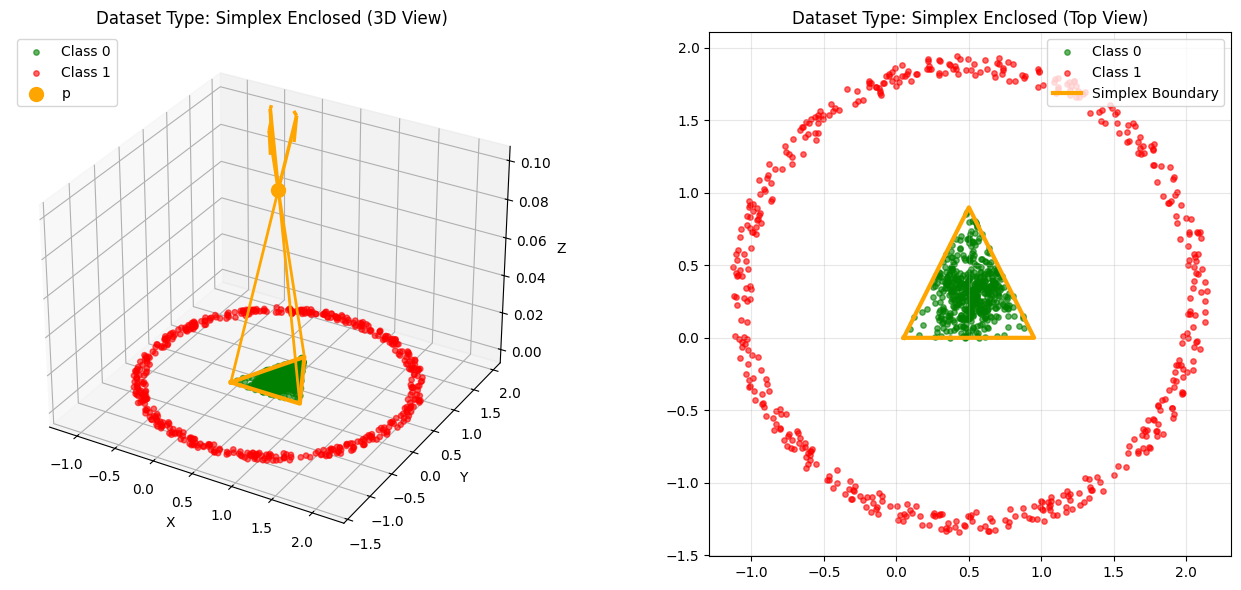

------------------------------------------------


In [ ]:
def generate_dataset_d_and_cone_parameters():
    """
    Corollary 3.2 Dataset Construction:
      X1 lies strictly inside the simplex
      X2 lies strictly outside the simplex
      Geometry is lifted to R^{n+1} using as stated in the proof
    """

    selected_digits = [0,1]
    Q = len(selected_digits)
    L = Q + 1

    print(f"DATA: Using Synthetic Simplex-Enclosed Class (Corollary 3.2 & Figure 1b in Ewa25).\n")
    dataset_info = "DATA: Using Synthetic Simplex-Enclosed Class (Corollary 3.2 & Figure 1b in Ewa25)"

    S = np.array([
        [0.05, 0.00],
        [0.95, 0.00],
        [0.50, 0.90],
    ], dtype=float)

    centroid = S.mean(axis=0)
    S3 = np.c_[S, np.zeros(3)]

    # "choose p a positive distance away from the hyperplane" — Cor.3.2
    p = np.array([centroid[0], centroid[1], 0.1], dtype=float)

    # "v_i := p - s_i" — Eq (3.11)
    v1, v2, v3 = p - S3[0], p - S3[1], p - S3[2]


    # Guarantees "X1 ⊂ S" and strictly interior per Corollary 3.2
    M = S.T

    def barycentric(x):
        A = np.linalg.lstsq(M, x.T, rcond=None)[0].T
        s = A.sum(axis=1, keepdims=True)
        s[s == 0] = 1.0
        return A/s

    def strictly_inside_simplex(x, eps=1e-9):
        return np.all(barycentric(x) > eps, axis=1)

    # Class 0 = X1 inside S
    n0 = 500

    def sample_inside_simplex(n, shrink=0.06):
        a = np.random.rand(n,3)
        a /= a.sum(axis=1, keepdims=True)
        pts = a @ S
        mask = strictly_inside_simplex(pts)
        if not np.all(mask):
            pts = pts[mask]
            while pts.shape[0] < n:
                need = n - pts.shape[0]
                a2 = np.random.rand(need,3)
                a2 /= a2.sum(axis=1, keepdims=True)
                extra = (1-shrink)*(a2@S) + shrink*centroid
                extra = extra[strictly_inside_simplex(extra)]
                pts = np.vstack([pts, extra])[:n]
        return pts

    X0_2d = sample_inside_simplex(n0)

    # Class 1 = X2 outside S
    n1 = 500

    def sample_outside_simplex(n, ring_inner_scale=2.5, ring_outer_scale=2.75):
        pts = []
        rad_vertices = np.linalg.norm(S - centroid, axis=1)
        r_in = rad_vertices.max()*ring_inner_scale
        r_out = rad_vertices.max()*ring_outer_scale

        while len(pts) < n:
            m = max(2000, 4*(n-len(pts)))
            theta = np.random.uniform(0,2*np.pi,m)
            r = np.sqrt(np.random.uniform(r_in**2,r_out**2,m))
            cand = np.column_stack([centroid[0]+r*np.cos(theta),
                                    centroid[1]+r*np.sin(theta)])

            # inside = strictly_inside_simplex(cand)
            # keep = cand[~inside]
            # pts.extend(keep.tolist())

            pts.extend(cand.tolist())
        return np.array(pts[:n])

    X1_2d = sample_outside_simplex(n1)

    y0 = np.zeros(X0_2d.shape[0], dtype=int)  # Class X1 inside simplex
    y1 = np.ones(X1_2d.shape[0], dtype=int)   # Class X2 outside simplex

    X2d = np.vstack([X0_2d, X1_2d])
    y = np.concatenate([y0, y1])

    # "include the data into R^{n+1} via ι := ι(n,n+1)" — Corollary 3.2 proof
    X = np.hstack([X2d, np.zeros((X2d.shape[0], 1))])


    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, stratify=y
    )

    X_train_tensor = torch.tensor(X_train, dtype=torch.float32)
    X_test_tensor  = torch.tensor(X_test, dtype=torch.float32)
    y_train_tensor = torch.tensor(y_train, dtype=torch.long)
    y_test_tensor  = torch.tensor(y_test, dtype=torch.long)

    train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
    test_dataset  = TensorDataset(X_test_tensor, y_test_tensor)

    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

    #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    # Visualize Generated Dataset + simplex + p + (v1,v2,v3)
    #-------------------------------------------------------------------------------------------------------------------------------------------------------------
    print('----------- VISUALIZING THE GENERATED SYNTHETIC DATA -----------\n')

    fig = plt.figure(figsize=(14, 6))

    ax1 = fig.add_subplot(1, 2, 1, projection='3d')
    colors = ['green', 'red']
    for label in np.unique(y):
        ax1.scatter(X[y == label, 0], X[y == label, 1], X[y == label, 2],
                    color=colors[int(label)], label=f'Class {int(label)}', alpha=0.6, s=15)

    cyc = np.vstack([S3, S3[0]])
    ax1.plot(cyc[:, 0], cyc[:, 1], cyc[:, 2], color='orange', lw=3, zorder=10)


    ax1.scatter([p[0]], [p[1]], [p[2]], c='orange', s=100, label='p')
    arrow_scale = 0.20

    for s_i, v in zip(S3, [v1, v2, v3]):
        v_norm = v / (np.linalg.norm(v) + 1e-12)

        ax1.plot([s_i[0], p[0]],
                [s_i[1], p[1]],
                [s_i[2], p[2]],
                color='orange', linewidth=2, zorder=10)

        ax1.quiver(p[0], p[1], p[2],
                  v_norm[0], v_norm[1], v_norm[2],
                  length=arrow_scale,
                  arrow_length_ratio=0.15,
                  color='orange',
                  linewidth=2.5,
                  zorder=11)

    ax1.set_title("Dataset Type: Simplex Enclosed (3D View)")
    ax1.set_xlabel("X")
    ax1.set_ylabel("Y")
    ax1.set_zlabel("Z")
    ax1.legend(loc='upper left')

    ax2 = fig.add_subplot(1, 2, 2)
    for label in np.unique(y):
        ax2.scatter(X[y == label, 0], X[y == label, 1],
                    color=colors[int(label)], alpha=0.6, s=15,
                    label=f'Class {int(label)}')

    cyc2 = np.vstack([S, S[0]])
    ax2.plot(cyc2[:, 0], cyc2[:, 1],
            color='orange', lw=3, zorder=10,
            label='Simplex Boundary')

    ax2.set_aspect('equal')
    ax2.set_title("Dataset Type: Simplex Enclosed (Top View)")
    ax2.grid(alpha=0.3)
    ax2.legend(loc='upper right')

    plt.tight_layout()
    plt.show()

    print('------------------------------------------------')

    # ----------------------------------------------------------------------------------------------------------------------
    # Define cone base points, generating vectors, and parameters (Patrícia's construction, Ewa25 Lemma 2.1)
    # ----------------------------------------------------------------------------------------------------------------------

    # Dataset Type D
    X_train = X_train
    y_train = y_train
    train_loader = train_loader

    # begin construction here!.....
    # -------------------------------------------------------------
    # FIRST CONE (Class 0 collapse) — Ewa25 Corollary 3.2
    # -------------------------------------------------------------

    # Stack the 3 generators into a matrix V₁ = [v1 v2 v3]
    V1 = np.column_stack([v1, v2, v3])

    # Compute the cumulative parameters (Lemma 2.1)
    W_cum1 = np.linalg.pinv(V1)    # (W)+ = V^+
    b_cum1 = - W_cum1 @ p          # b = - W p

    # -------------------------------------------------------------
    # SECOND CONE (Class 1 collapse) — Ewa25 Corollary 3.2
    # -------------------------------------------------------------

    # Choose a second apex p2 above simplex, separated from p
    # (This ensures two different collapse points)
    p2 = p + np.array([0.0, 0.0, 0.04])  # adjust 0.3 if needed

    small_z = 0.09

    # New generator vectors  ṽ_i = p2 - s_i'
    v1_t = -(p2 - S3[0]) + [0, 0, small_z]
    v2_t = -(p2 - S3[1]) + [0, 0, small_z]
    v3_t = -(p2 - S3[2]) + [0, 0, small_z]

    # Stack into matrix  V2 = [ṽ1 ṽ2 ṽ3]
    V2 = np.column_stack([v1_t, v2_t, v3_t])

    # Apply Lemma 2.1 for second truncation map
    W_cum2 = np.linalg.pinv(V2)
    b_cum2 = - W_cum2 @ p2


    # -------------------------------------------------------------
    # FINAL AFFINE CLASSIFIER (CE24 Theorem 6)
    # -------------------------------------------------------------

    # apex matrix P = [p, p2]
    P = np.stack([p, p2], axis=1)     # shape (3,2)

    # one-hot labels
    Y = np.eye(2)

    # W maps apices to labels
    W_cum3 = Y @ np.linalg.pinv(P)
    b_cum3 = np.zeros(2)

    # -------------------------------------------------------------
    # Convert cumulative -> layerwise (CE24 equations (5)-(6))
    # -------------------------------------------------------------

    def cumulative_to_layerwise(W_list, b_list):
        Ws, bs = [W_list[0]], [b_list[0]]
        for i in range(1, len(W_list)):
            Wi = W_list[i] @ np.linalg.pinv(W_list[i-1])
            bi = b_list[i] - Wi @ b_list[i-1]
            Ws.append(Wi)
            bs.append(bi)
        return Ws, bs

    W_list = [W_cum1, W_cum2, W_cum3]
    b_list = [b_cum1, b_cum2, b_cum3]

    Ws, bs = cumulative_to_layerwise(W_list, b_list)

    # -------------------------------------------------------------
    # Return Dataset D parameters
    # -------------------------------------------------------------
    return Ws, bs, X_train, y_train, train_loader, dataset_info


#------------- ONLY ALTER VALUES BELOW -------------
_ = generate_dataset_d_and_cone_parameters()

## **Step No. 3 - Building Zero Construction Loss ReLU Network**


DATA: Using Synthetic Simplex-Enclosed Class (Corollary 3.2 & Figure 1b in Ewa25).

----------- VISUALIZING THE GENERATED SYNTHETIC DATA -----------



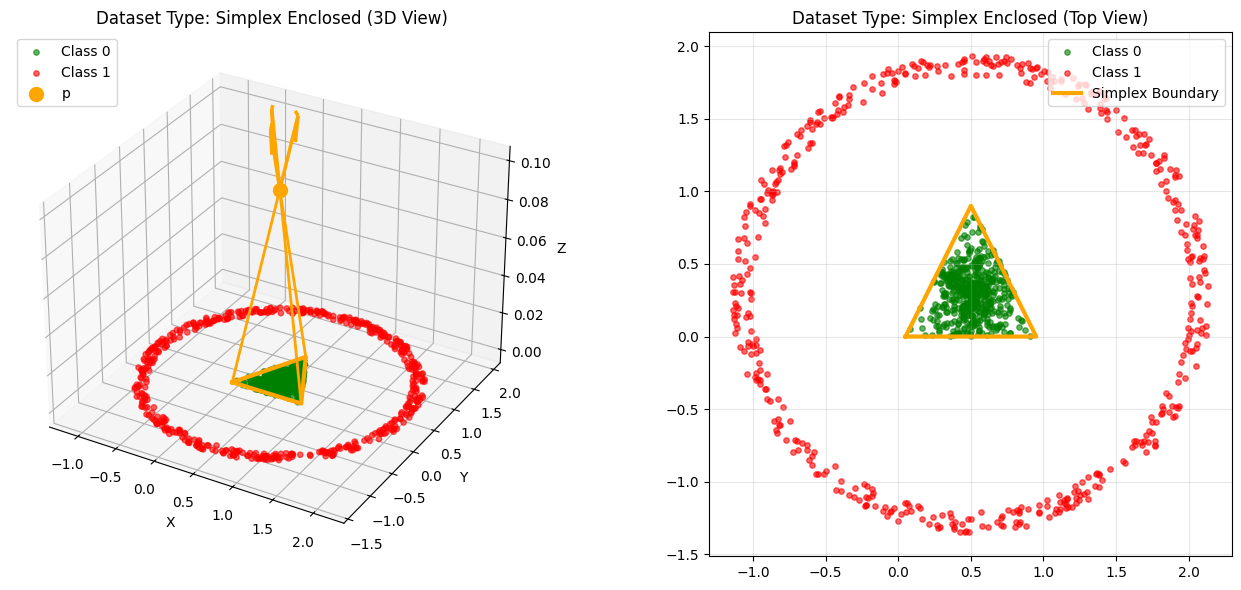

------------------------------------------------

 Construction accuracy (analytic CE24/Ewa25 initialization): 100.00%, loss=0.00000



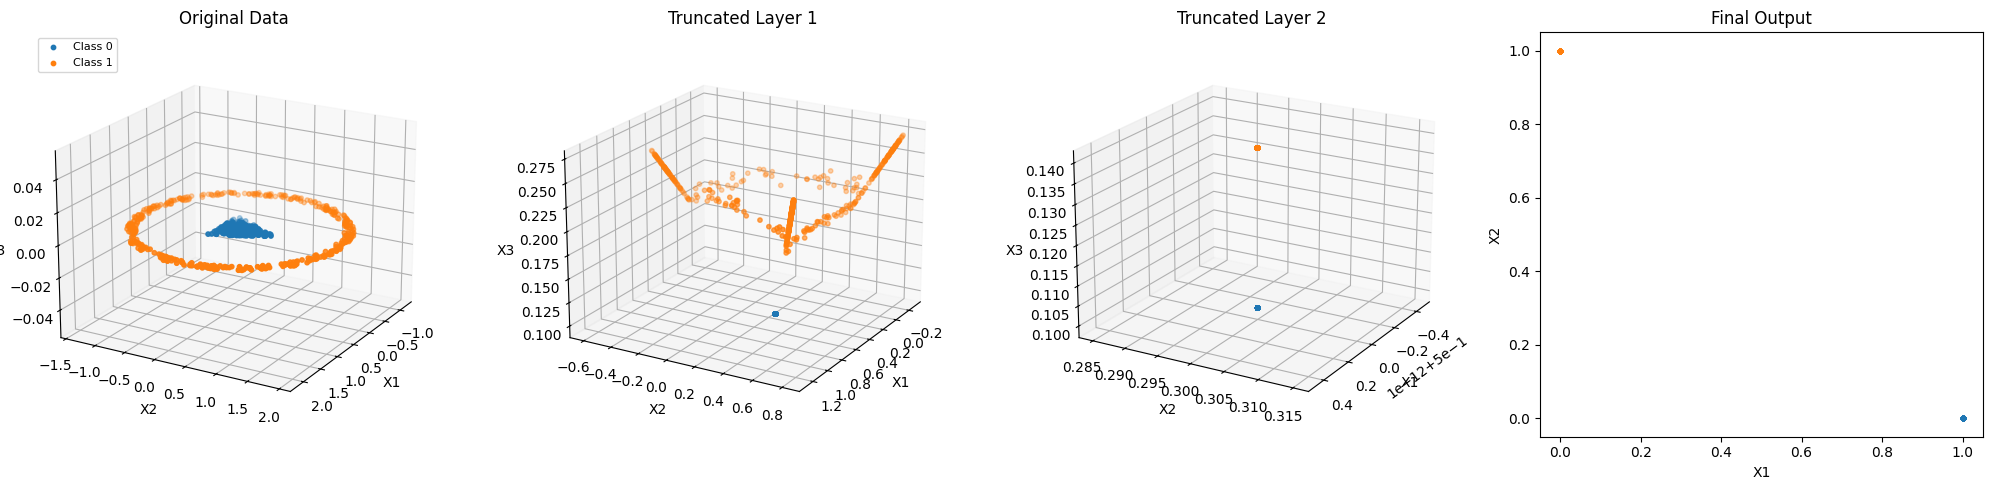

In [ ]:
# -----------------------------------------------------------------------------------------------------------
# Implements the explicit ReLU network with layerwise weights (Wₗ, bₗ) from CE24 Eq. (1) / Ewa25 Eq. (2.1)
# -----------------------------------------------------------------------------------------------------------

class ExplicitReLU(nn.Module):
    def __init__(self, Ws, bs):
        super().__init__()
        self.layers = nn.ModuleList([
            nn.Linear(Ws[i].shape[1], Ws[i].shape[0]) for i in range(len(Ws))
        ])

        for i, l in enumerate(self.layers):
            l.weight.data = torch.tensor(Ws[i], dtype=torch.float32)
            l.bias.data   = torch.tensor(bs[i], dtype=torch.float32)

    def forward(self, x):
        # CE24/Ewa25: ReLU after each layer except the final linear layer
        for layer in self.layers[:-1]:
            x = F.relu(layer(x))
        return self.layers[-1](x)

def zero_loss_check(Ws, bs, X, y):
    m = ExplicitReLU(Ws, bs).eval()
    Xt = torch.tensor(X, dtype=torch.float32)
    yt = torch.tensor(y, dtype=torch.long)
    criterion = nn.CrossEntropyLoss()

    with torch.no_grad():
        out = m(Xt) *50.0 # change if needed
        loss = criterion(out, yt)
        acc = (out.argmax(1) == yt).float().mean().item()

    print(f"\n Construction accuracy (analytic CE24/Ewa25 initialization): {acc*100:.2f}%, loss={loss:.5f}\n")
    plot_truncated(Ws, bs, X, y)
    return m, acc

#------------- ONLY ALTER VALUES BELOW -------------
# Zero Loss Construction Parameters for Synthetic Dataset A
# Zero Loss Construction Parameters for Synthetic Dataset B
# Ws, bs, X_train, y_train, train_loader, dataset_info = generate_dataset_c_and_cone_parameters(sep=0.35) # Zero Loss Construction Parameters for Synthetic Dataset C
Ws, bs, X_train, y_train, train_loader, dataset_info = generate_dataset_d_and_cone_parameters() # Zero Loss Construction Parameters for Synthetic Dataset D
_ = zero_loss_check(Ws, bs, X_train, y_train)

## **Step 4 – Creating $\lambda$ Perturbations to Visualize Loss Landscape**

DATA: Using Synthetic Simplex-Enclosed Class (Corollary 3.2 & Figure 1b in Ewa25).

----------- VISUALIZING THE GENERATED SYNTHETIC DATA -----------



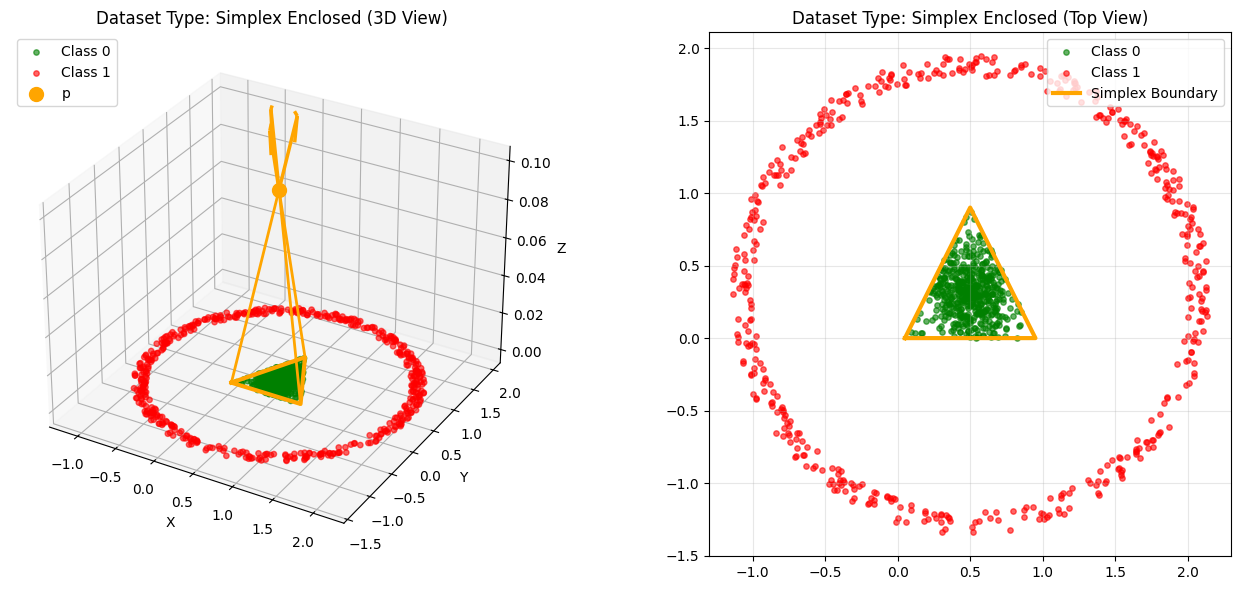

------------------------------------------------
λ=0.0150 | loss=0.05209±0.00016 | acc=100.00%±0.00%
λ=0.1050 | loss=0.05180±0.00112 | acc=100.00%±0.00%
λ=0.1950 | loss=0.04940±0.00391 | acc=100.00%±0.00%
λ=0.2850 | loss=0.05029±0.00640 | acc=100.00%±0.00%
λ=0.3750 | loss=0.05014±0.00709 | acc=100.00%±0.00%
λ=0.4650 | loss=0.04907±0.00652 | acc=100.00%±0.00%
λ=0.5550 | loss=0.04982±0.00687 | acc=100.00%±0.00%
λ=0.6450 | loss=0.04974±0.00780 | acc=100.00%±0.00%
λ=0.7350 | loss=0.04931±0.00842 | acc=100.00%±0.00%
λ=0.8250 | loss=0.04669±0.00873 | acc=100.00%±0.00%
λ=0.9150 | loss=0.04614±0.01206 | acc=100.00%±0.00%
λ=1.0050 | loss=0.11182±0.19433 | acc=95.00%±15.00%
λ=1.0950 | loss=0.16287±0.22690 | acc=92.26%±16.28%
λ=1.1850 | loss=0.20982±0.25992 | acc=88.77%±17.90%
λ=1.2750 | loss=0.23727±0.25396 | acc=87.61%±17.61%
λ=1.3650 | loss=0.23807±0.25389 | acc=87.62%±17.60%
λ=1.4550 | loss=0.24039±0.25434 | acc=87.51%±17.62%
λ=1.5450 | loss=0.24120±0.25400 | acc=87.45%±17.65%
λ=1.6350 | loss

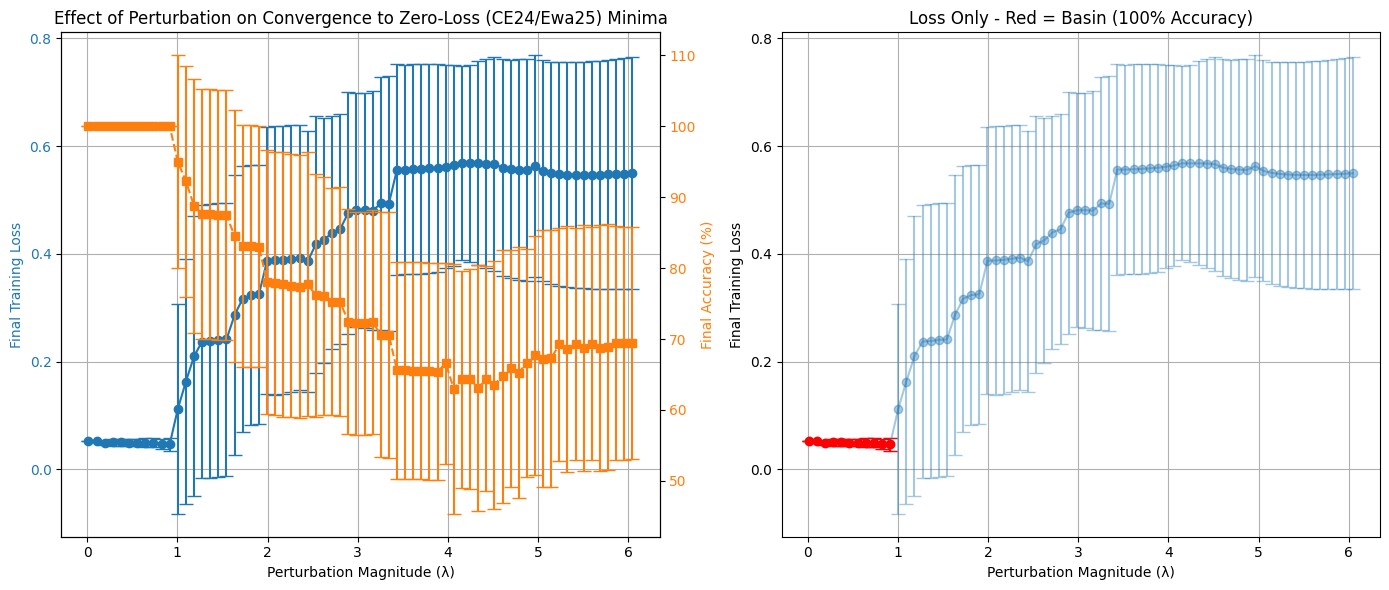

In [ ]:
# -----------------------------------------------------------------------------------------------------------
# Effect of λ Perturbations on Loss and Convergence (wrapped into one configurable method)
# -----------------------------------------------------------------------------------------------------------

def run_lambda_perturbation_experiment(Ws, bs, X_train, y_train, lambda_start=0.015, lambda_end=1.005, lambda_step=0.015, trials_per_lambda=10, epochs=1000, lr=0.01, dataset_info=dataset_info, verbose=False):

    def clone_model(Ws, bs):
        # Constructions from [CE24] and [Ewa25] used to find zero-cost global minima
        return deepcopy(Ws), deepcopy(bs)

    def add_perturbation(Ws, bs, lambda_val, seed=None):
        if seed is not None:
            np.random.seed(seed)
        perturbed_Ws, perturbed_bs = [], []

        # Add normalized Gaussian noise to each weight matrix
        for W in Ws:
            noise = np.random.randn(*W.shape)
            noise_norm = np.linalg.norm(noise)
            delta_W = (lambda_val / noise_norm) * noise  # scale noise to have norm = λ
            perturbed_Ws.append(W + delta_W)

        # Add normalized Gaussian noise to each bias vector
        for b in bs:
            noise = np.random.randn(*b.shape)
            noise_norm = np.linalg.norm(noise)
            delta_b = (lambda_val / noise_norm) * noise
            perturbed_bs.append(b + delta_b)

        return perturbed_Ws, perturbed_bs

    def train_network(perturbed_Ws, perturbed_bs, X_train, y_train, epochs=1000, lr=0.01, verbose=False):
        # "Use this perturbed vector to initialize, then see what SGD converges to"
        model = ExplicitReLU(deepcopy(perturbed_Ws), deepcopy(perturbed_bs))
        model.train()

        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()

        X_tensor = torch.tensor(X_train, dtype=torch.float32)
        y_tensor = torch.tensor(y_train, dtype=torch.long)

        # Perform gradient descent to see if the network 'flows back' to zero-loss basin
        for epoch in range(epochs):
            optimizer.zero_grad()
            outputs = model(X_tensor)
            loss = criterion(outputs, y_tensor)
            loss.backward()
            optimizer.step()

            if verbose and epoch % 100 == 0:
                print(f"Epoch {epoch} | Loss: {loss.item():.4f}")

        final_loss = loss.item()
        preds = outputs.argmax(dim=1)
        acc = (preds == y_tensor).float().mean().item()

        return final_loss, acc, model

    def run_experiment_across_lambdas(Ws, bs, X_train, y_train, lambda_vals, trials_per_lambda=10, epochs=1000, lr=0.01):
        # Smaller/larger norms (λ), multiple random perturbations, and average the final losses per lambda
        results = {}

        for lambda_val in lambda_vals:
            trial_losses, trial_accuracies = [], []
            Ws_list, bs_list = [], []

            for trial in range(trials_per_lambda):
                perturbed_Ws, perturbed_bs = add_perturbation(Ws, bs, lambda_val, seed=trial)
                loss, acc, trained_model = train_network(perturbed_Ws, perturbed_bs, X_train, y_train, epochs=epochs, lr=lr)
                trial_losses.append(loss)
                trial_accuracies.append(acc)

                Ws_final = [l.weight.detach().numpy().copy() for l in trained_model.layers]
                bs_final = [l.bias.detach().numpy().copy() for l in trained_model.layers]
                Ws_list.append(Ws_final)
                bs_list.append(bs_final)

            avg_loss = np.mean(trial_losses)
            std_loss = np.std(trial_losses)
            avg_acc = np.mean(trial_accuracies)
            std_acc = np.std(trial_accuracies)

            results[lambda_val] = {
                'losses': trial_losses,
                'accuracies': trial_accuracies,
                'Ws_list': Ws_list,
                'bs_list': bs_list,
                'dataset_info': dataset_info
            }

            print(f"λ={lambda_val:.4f} | loss={avg_loss:.5f}±{std_loss:.5f} | acc={avg_acc*100:.2f}%±{std_acc*100:.2f}%")

        return results

    def plot_loss_vs_lambda(results):
        import matplotlib.pyplot as plt

        lambdas = list(results.keys())
        mean_losses = [np.mean(results[λ]['losses']) for λ in lambdas]
        std_losses = [np.std(results[λ]['losses']) for λ in lambdas]
        mean_accs = [np.mean(results[λ]['accuracies']) for λ in lambdas]

        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [2, 2]})

        # ----- Left Plot (Standard Loss & Accuracy Plot) -----
        ax1.errorbar(lambdas, mean_losses, yerr=std_losses, fmt='o-', capsize=5, color='tab:blue')
        ax1.set_xlabel("Perturbation Magnitude (λ)")
        ax1.set_ylabel("Final Training Loss", color='tab:blue')
        ax1.tick_params(axis='y', labelcolor='tab:blue')
        ax1.grid(True)

        ax3 = ax1.twinx()
        mean_accs_percent = [acc * 100 for acc in mean_accs]
        std_accs_percent = [np.std(results[λ]['accuracies']) * 100 for λ in lambdas]
        ax3.errorbar(lambdas, mean_accs_percent, yerr=std_accs_percent, fmt='s--', capsize=5, color='tab:orange')
        ax3.set_ylabel("Final Accuracy (%)", color='tab:orange')
        ax3.tick_params(axis='y', labelcolor='tab:orange')

        ax1.set_title("Effect of Perturbation on Convergence to Zero-Loss (CE24/Ewa25) Minima")

        # ----- Right Plot (Loss Only + Connected Line + Red Highlights for 100% Acc) -----
        ax2.errorbar(lambdas, mean_losses, yerr=std_losses, fmt='o-', capsize=5, color='tab:blue', alpha=0.4)

        for i, λ in enumerate(lambdas):
            if mean_accs[i] == 1.0:
                ax2.errorbar(λ, mean_losses[i], yerr=std_losses[i], fmt='o', capsize=5, color='red')

        ax2.set_xlabel("Perturbation Magnitude (λ)")
        ax2.set_ylabel("Final Training Loss")
        ax2.grid(True)
        ax2.set_title("Loss Only - Red = Basin (100% Accuracy)")
        plt.tight_layout()
        plt.show()

    # ---- Run the λ sweep ----
    lambda_values = list(np.arange(lambda_start, lambda_end + lambda_step, lambda_step))
    results = run_experiment_across_lambdas(Ws, bs, X_train, y_train, lambda_values,
                                            trials_per_lambda=trials_per_lambda, epochs=epochs, lr=lr, )
    plot_loss_vs_lambda(results)
    return results

#------------- ONLY ALTER VALUES BELOW -------------
# Ws, bs, X_train, y_train, train_loader, dataset_info = generate_dataset_c_and_cone_parameters(sep=0.35) # Zero Loss Construction Parameters for Synthetic Dataset C
# results_lambda = run_lambda_perturbation_experiment(
#     Ws, bs, X_train, y_train,
#     lambda_start=0.015,
#     lambda_end=1.015,
#     lambda_step=0.015,
#     trials_per_lambda=10,
#     epochs=1000,
#     lr=0.01,
#     dataset_info=dataset_info
# )

Ws, bs, X_train, y_train, train_loader, dataset_info = generate_dataset_d_and_cone_parameters() # Zero Loss Construction Parameters for Synthetic Dataset D
results_lambda = run_lambda_perturbation_experiment(
    Ws, bs, X_train, y_train,
    lambda_start=0.015,
    lambda_end=6.015,
    lambda_step=0.09,
    trials_per_lambda=10,
    epochs=1000,
    lr=0.01,
    dataset_info=dataset_info
)

> **Step 4a – Visualizing $\lambda$ Perturbations with Truncation Maps**


=== Dataset Info ===
DATA: Using Synthetic Simplex-Enclosed Class (Corollary 3.2 & Figure 1b in Ewa25)

Enter λ value to visualize: 0.64
Nearest computed λ → 0.6450
Average Loss = 0.04974 | Average Accuracy = 100.00%
Select trial index (0–9): 1
Trial 1: Loss=0.05032, Acc=100.00%


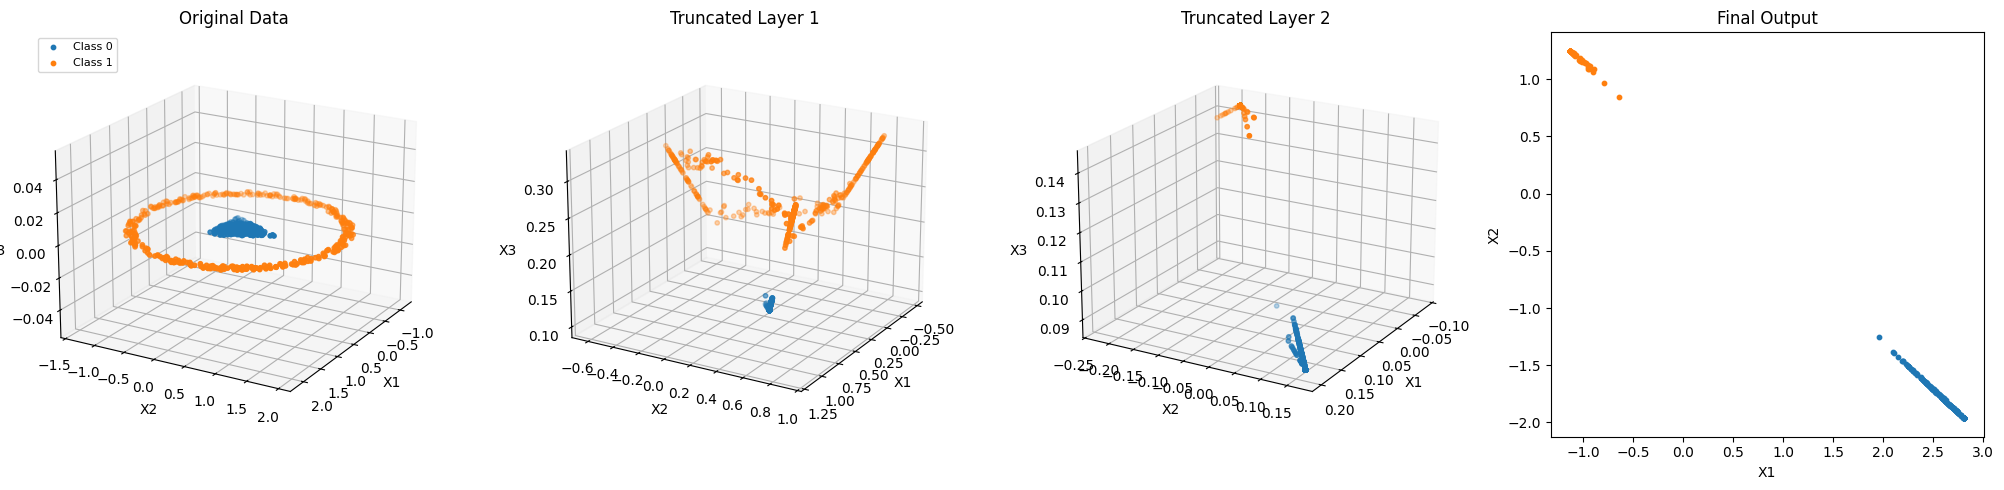

In [ ]:
print("\n=== Dataset Info ===")
print(results_lambda[next(iter(results_lambda))]['dataset_info'])  # grabs from first λ entry
print("====================\n")

lambda_input = float(input("Enter λ value to visualize: "))
lambda_sel = min(results_lambda.keys(), key=lambda l: abs(l - lambda_input))
print(f"Nearest computed λ → {lambda_sel:.4f}")

losses = results_lambda[lambda_sel]['losses']
accuracies = results_lambda[lambda_sel]['accuracies']
avg_loss = np.mean(losses)
avg_acc = np.mean(accuracies)
print(f"Average Loss = {avg_loss:.5f} | Average Accuracy = {avg_acc*100:.2f}%")

trial_idx = int(input(f"Select trial index (0–{len(losses)-1}): "))

# Use stored trained Ws and bs directly
Ws_sel = results_lambda[lambda_sel]['Ws_list'][trial_idx]
bs_sel = results_lambda[lambda_sel]['bs_list'][trial_idx]

print(f"Trial {trial_idx}: Loss={losses[trial_idx]:.5f}, Acc={accuracies[trial_idx]*100:.2f}%")
plot_truncated(Ws_sel, bs_sel, X_train, y_train)

## **Step No. 5 - Creating $\alpha$ and $\beta$ Perturbations to Visualize 3D Loss Landscape & Accuracy Basin**



DATA: Using Synthetic Simplex-Enclosed Class (Corollary 3.2 & Figure 1b in Ewa25).

----------- VISUALIZING THE GENERATED SYNTHETIC DATA -----------



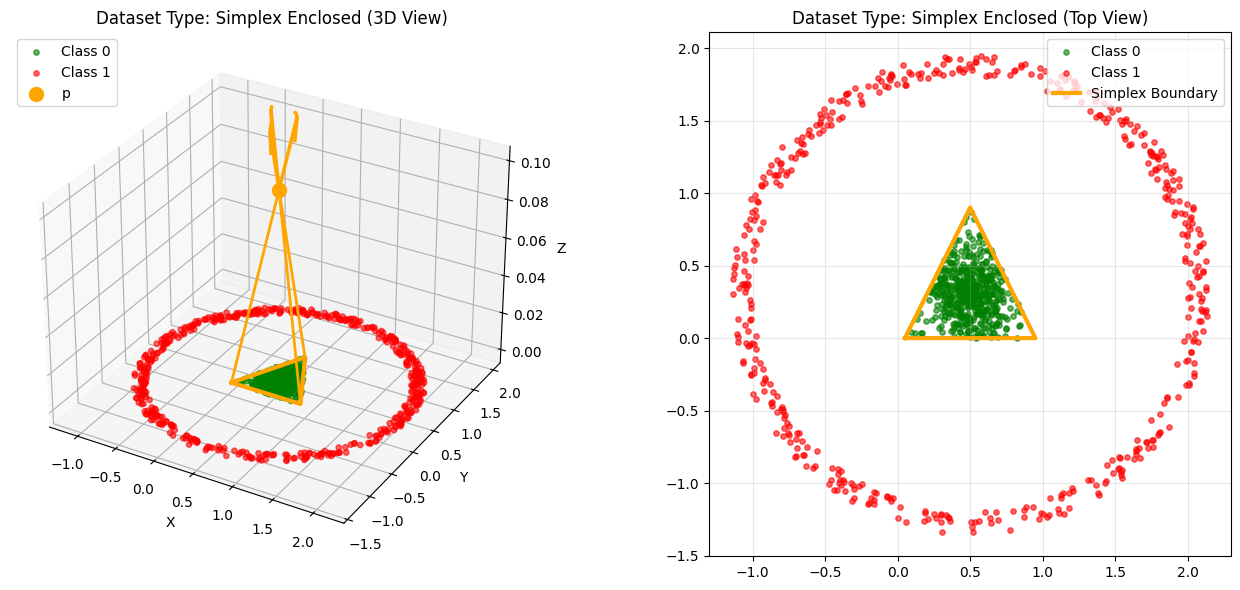

------------------------------------------------
(α=-5.000, β=-5.000) | loss=0.69315 | acc=50.00%
(α=-5.000, β=-4.474) | loss=0.69315 | acc=50.00%
(α=-5.000, β=-3.947) | loss=0.69315 | acc=50.00%
(α=-5.000, β=-3.421) | loss=0.51730 | acc=72.12%
(α=-5.000, β=-2.895) | loss=0.51798 | acc=72.00%
(α=-5.000, β=-2.368) | loss=0.34916 | acc=89.88%
(α=-5.000, β=-1.842) | loss=0.34886 | acc=89.25%
(α=-5.000, β=-1.316) | loss=0.35248 | acc=87.75%
(α=-5.000, β=-0.789) | loss=0.35345 | acc=87.88%
(α=-5.000, β=-0.263) | loss=0.35388 | acc=88.25%
(α=-5.000, β=0.263) | loss=0.35647 | acc=89.63%
(α=-5.000, β=0.789) | loss=0.36431 | acc=90.13%
(α=-5.000, β=1.316) | loss=0.09627 | acc=100.00%
(α=-5.000, β=1.842) | loss=0.09212 | acc=99.50%
(α=-5.000, β=2.368) | loss=0.08943 | acc=99.37%
(α=-5.000, β=2.895) | loss=0.08705 | acc=99.37%
(α=-5.000, β=3.421) | loss=0.08527 | acc=99.25%
(α=-5.000, β=3.947) | loss=0.08415 | acc=99.00%
(α=-5.000, β=4.474) | loss=0.08354 | acc=98.50%
(α=-5.000, β=5.000) | loss=0

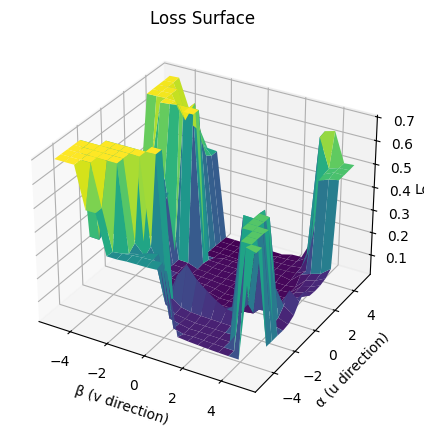

In [ ]:
def two_d_perturbation_experiment(Ws, bs, X_train, y_train,
                                  alpha_min, alpha_max,
                                  beta_min, beta_max,
                                  num_points, epochs, lr,
                                  dataset_info):

    # -----------------------------------------------------------------------------------------------------------
    # Step 5 – Effect of 2D Perturbations (α·u + β·v) on Loss Landscape and Convergence
    # -----------------------------------------------------------------------------------------------------------

    # λ = α·u + β·v is a 2D perturbation vector in parameter space
    # since u and v are orthonormal -> ||u|| = ||v|| = 1 and u ⊥ v
    # the perturbation norm is: ||λ|| = root(α² + β²)
    # so iterating α, β over a grid implicitly varies ||λ||

    def flatten_params(Ws, bs):
        return np.concatenate([W.flatten() for W in Ws] + [b.flatten() for b in bs])

    def unflatten_params(flat, Ws_shapes, bs_shapes):
        Ws, bs = [], []
        idx = 0
        for shape in Ws_shapes:
            size = np.prod(shape)
            Ws.append(flat[idx:idx+size].reshape(shape))
            idx += size
        for shape in bs_shapes:
            size = np.prod(shape)
            bs.append(flat[idx:idx+size].reshape(shape))
            idx += size
        return Ws, bs

    # Initialize θ and construct two orthonormal directions u, v
    def init_uv(Ws, bs):
        theta = flatten_params(Ws, bs) # zero-loss construction
        dim = theta.shape[0]
        u = np.random.randn(dim) # random direction u
        u = u / np.linalg.norm(u)
        v_raw = np.random.randn(dim) # make v orthogonal to u
        v = v_raw - np.dot(v_raw, u) * u
        v = v / np.linalg.norm(v)
        return theta, u, v

    # Apply 2D perturbation along α·u + β·v
    def apply_2d_perturbation(theta, u, v, alpha, beta, Ws_shapes, bs_shapes):
        perturbed_theta = theta + alpha * u + beta * v
        return unflatten_params(perturbed_theta, Ws_shapes, bs_shapes)

    # Train model initialized with (α, β) perturbation
    def train_network(perturbed_Ws, perturbed_bs, X_train, y_train, epochs=1000, lr=0.01, verbose=False):
        model = ExplicitReLU(deepcopy(perturbed_Ws), deepcopy(perturbed_bs))
        model.train()
        optimizer = torch.optim.SGD(model.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()

        X_tensor = torch.tensor(X_train, dtype=torch.float32)
        y_tensor = torch.tensor(y_train, dtype=torch.long)

        for epoch in range(epochs):
            optimizer.zero_grad()
            outputs = model(X_tensor)
            loss = criterion(outputs, y_tensor)
            loss.backward()
            optimizer.step()

        final_loss = loss.item()
        preds = outputs.argmax(dim=1)
        acc = (preds == y_tensor).float().mean().item()
        return final_loss, acc, model

    def run_2d_experiment(Ws, bs, X_train, y_train, alpha_vals, beta_vals, epochs=1000, lr=0.01):
        theta, u, v = init_uv(Ws, bs)
        Ws_shapes = [W.shape for W in Ws]
        bs_shapes = [b.shape for b in bs]

        results = {}
        for alpha in alpha_vals:
            for beta in beta_vals:
                if alpha == 0 and beta == 0:
                    continue

                perturbed_Ws, perturbed_bs = apply_2d_perturbation(theta, u, v, alpha, beta, Ws_shapes, bs_shapes)
                loss, acc, model = train_network(perturbed_Ws, perturbed_bs, X_train, y_train, epochs=epochs, lr=lr)

                Ws_final = [l.weight.detach().numpy().copy() for l in model.layers]
                bs_final = [l.bias.detach().numpy().copy() for l in model.layers]

                results[(alpha, beta)] = {
                    'loss': loss,
                    'acc': acc,
                    'Ws': Ws_final,
                    'bs': bs_final,
                    'dataset_info': dataset_info
                }

                print(f"(α={alpha:.3f}, β={beta:.3f}) | loss={loss:.5f} | acc={acc*100:.2f}%")

        return results

    def save_matplotlib_surface_as_image(results, alpha_vals, beta_vals, key='loss'):
        Z = np.array([[results[(a,b)][key] for b in beta_vals] for a in alpha_vals])
        A, B = np.meshgrid(beta_vals, alpha_vals)

        fig = plt.figure(figsize=(6, 5))
        ax = fig.add_subplot(111, projection='3d')
        surf = ax.plot_surface(A, B, Z, cmap='viridis', edgecolor='none')
        ax.set_xlabel('β (v direction)')
        ax.set_ylabel('α (u direction)')
        ax.set_zlabel(f'{key.capitalize()}')
        ax.set_title(f'{key.capitalize()} Surface')

        buf = io.BytesIO()
        plt.savefig(buf, format='png')
        buf.seek(0)
        img = Image.open(buf)
        return img

    def plot_combined_surface_and_basin(results, alpha_vals, beta_vals):

        img = save_matplotlib_surface_as_image(results, alpha_vals, beta_vals)
        Z = np.array([[results[(a, b)]['loss'] for b in beta_vals] for a in alpha_vals])
        ACC = np.array([[results[(a, b)]['acc'] for b in beta_vals] for a in alpha_vals])

        basin_mask = (ACC == 1.0)
        threshold = Z[basin_mask].max() if np.any(basin_mask) else Z.min()
        surface_mask = np.where(
            (ACC == 1.0) & (Z <= threshold),
            0.0,
            (Z - Z.min()) / (Z.max() - Z.min()) * 0.9 + 0.1
        )

        custom_colorscale = [
            [0.0, 'red'], [0.001, 'red'],
            [0.1, 'rgb(68,1,84)'],
            [0.5, 'rgb(59,82,139)'],
            [0.75, 'rgb(33,145,140)'],
            [1.0, 'rgb(253,231,37)']
        ]

        fig = go.Figure(data=[go.Surface(
            z=Z, x=beta_vals, y=alpha_vals,
            surfacecolor=surface_mask,
            colorscale=custom_colorscale,
            showscale=True,
            cmin=0, cmax=1,
            colorbar=dict(
                title='Loss Category',
                tickvals=[0, 0.5, 1],
                ticktext=['Basin (100%)', 'Mid', 'High']
            )
        )])

        fig.update_layout(
            title="Loss Surface with 100% Accuracy Basin Highlighted",
            scene=dict(
                xaxis_title="β (v direction)",
                yaxis_title="α (u direction)",
                zaxis_title="Loss"
            ),
            height=600,
            width=800
        )

        fig.show()

    # run the 2D perturbation experiment
    alpha_vals = np.linspace(alpha_min, alpha_max, num_points)
    beta_vals  = np.linspace(beta_min, beta_max, num_points)
    results = run_2d_experiment(Ws, bs, X_train, y_train, alpha_vals, beta_vals, epochs=epochs, lr=lr)
    plot_combined_surface_and_basin(results, alpha_vals, beta_vals)
    return results, alpha_vals, beta_vals

#------------- ONLY ALTER VALUES BELOW -------------
# # Zero Loss Construction Parameters for Synthetic Dataset A
# # Zero Loss Construction Parameters for Synthetic Dataset B
# Ws, bs, X_train, y_train, train_loader, dataset_info = generate_dataset_c_and_cone_parameters(sep=0.35) # Zero Loss Construction Parameters for Synthetic Dataset C
# results_a_b, alpha_vals, beta_vals = two_d_perturbation_experiment(
#     Ws, bs, X_train, y_train,
#     alpha_min=-5.0, alpha_max=5.0,
#     beta_min=-5.0, beta_max=5.0,
#     num_points=20, epochs=1000, lr=0.01, dataset_info=dataset_info
# )

Ws, bs, X_train, y_train, train_loader, dataset_info = generate_dataset_d_and_cone_parameters() # Zero Loss Construction Parameters for Synthetic Dataset D
results_a_b, alpha_vals, beta_vals = two_d_perturbation_experiment(
    Ws, bs, X_train, y_train,
    alpha_min=-5.0, alpha_max=5.0,
    beta_min=-5.0, beta_max=5.0,
    num_points=20, epochs=1000, lr=0.01, dataset_info=dataset_info
)

> **Step 5a – Visualizing $\alpha$ and $\beta$ Perturbations with Truncation Maps**


=== Dataset Info ===
DATA: Using Synthetic Dataset Type (c): 2 Non-SLS & Non-Concentric Classes (Figure 1a in Ewa25)

Enter α: 0.263
Enter β: 0.263
Nearest computed pair → α=0.263, β=0.263
Loss=0.0466, Acc=100.0%


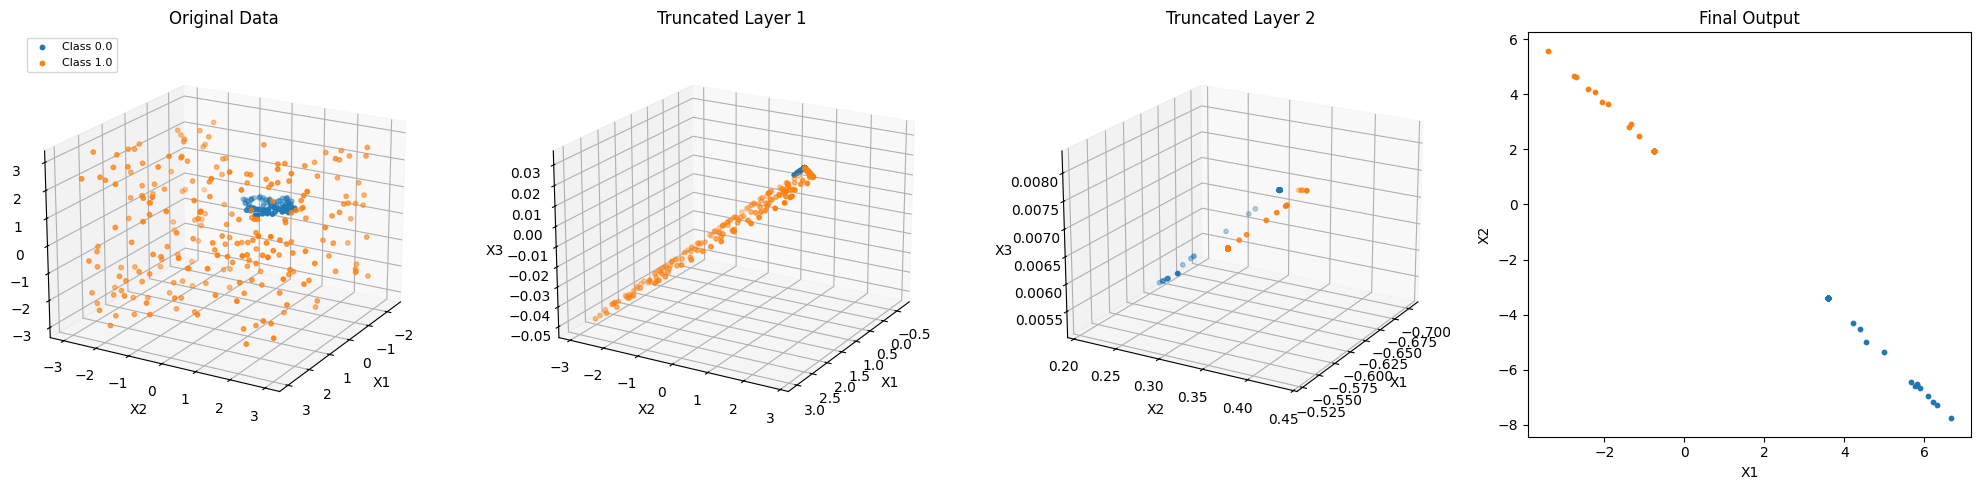

In [ ]:
print("\n=== Dataset Info ===")
print(results_a_b[next(iter(results_a_b))]['dataset_info'])
print("====================\n")

alpha = float(input("Enter α: "))
beta  = float(input("Enter β: "))

alpha_sel = min(alpha_vals, key=lambda a: abs(a - alpha))
beta_sel  = min(beta_vals, key=lambda b: abs(b - beta))

print(f"Nearest computed pair → α={alpha_sel:.3f}, β={beta_sel:.3f}")

Ws_sel = results_a_b[(alpha_sel, beta_sel)]['Ws']
bs_sel = results_a_b[(alpha_sel, beta_sel)]['bs']
print(f"Loss={results_a_b[(alpha_sel,beta_sel)]['loss']:.4f}, Acc={results_a_b[(alpha_sel,beta_sel)]['acc']*100:.1f}%")

plot_truncated(Ws_sel, bs_sel, X_train, y_train)